# Pipeline fMRI — Conectividad Funcional

Pipeline completo: carga → exploración → filtrado → parcelación → conectividad (correlación + Graphical Lasso).

In [1]:
# ── Imports globales ──────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import nibabel as nib
import ipywidgets as widgets
import os
from scipy.signal import butter, filtfilt
from nilearn import datasets
from nilearn.image import resample_to_img
%matplotlib widget

os.makedirs('resultados', exist_ok=True)
print('Imports OK')


Imports OK


## 1. Cargar datos

Descargamos 1 sujeto del dataset ABIDE. El TR se extrae directamente del header NIfTI.

In [2]:
abide = datasets.fetch_abide_pcp(
    data_dir='./data',
    n_subjects=1,
    pipeline='cpac',
    band_pass_filtering=False,
    global_signal_regression=False,
    derivatives=['func_preproc']
)

fmri_path = abide.func_preproc[0]
fmri_img  = nib.load(fmri_path)
data      = fmri_img.get_fdata()

# TR desde el header (en segundos)
TR = float(fmri_img.header.get_zooms()[3])

x_dim, y_dim, z_dim, t_dim = data.shape

print(f'Archivo : {fmri_path}')
print(f'Shape   : {data.shape}  (X, Y, Z, T)')
print(f'TR      : {TR} s')
print(f'Duración: {t_dim * TR:.1f} s  ({t_dim} volúmenes)')


Archivo : ./data\ABIDE_pcp\cpac\nofilt_noglobal\Pitt_0050003_func_preproc.nii.gz
Shape   : (61, 73, 61, 196)  (X, Y, Z, T)
TR      : 1.5 s
Duración: 294.0 s  (196 volúmenes)


## 2. Visor cerebral unificado

Widget con slider de corte `z`, selector de tiempo `t`, y clic sobre el cerebro para ver la señal del voxel (**original** en azul, **filtrada** en rojo). Todo en una sola figura.

In [3]:
# ── Filtro pasa-banda (se define aquí para usarlo en todo el notebook) ──
def bandpass_filter(signal, lowcut=0.01, highcut=0.1, tr=2.0):
    """
    Filtro Butterworth orden 4, pasa-banda 0.01-0.1 Hz.
    Estándar para fMRI en reposo (elimina drift lento y ruido fisiológico rápido).
    """
    fs  = 1.0 / tr
    nyq = fs / 2.0
    low  = max(lowcut  / nyq, 1e-6)
    high = min(highcut / nyq, 0.9999)
    b, a = butter(4, [low, high], btype='band')
    return filtfilt(b, a, signal)

print('bandpass_filter() definida — TR =', TR, 's')


bandpass_filter() definida — TR = 1.5 s


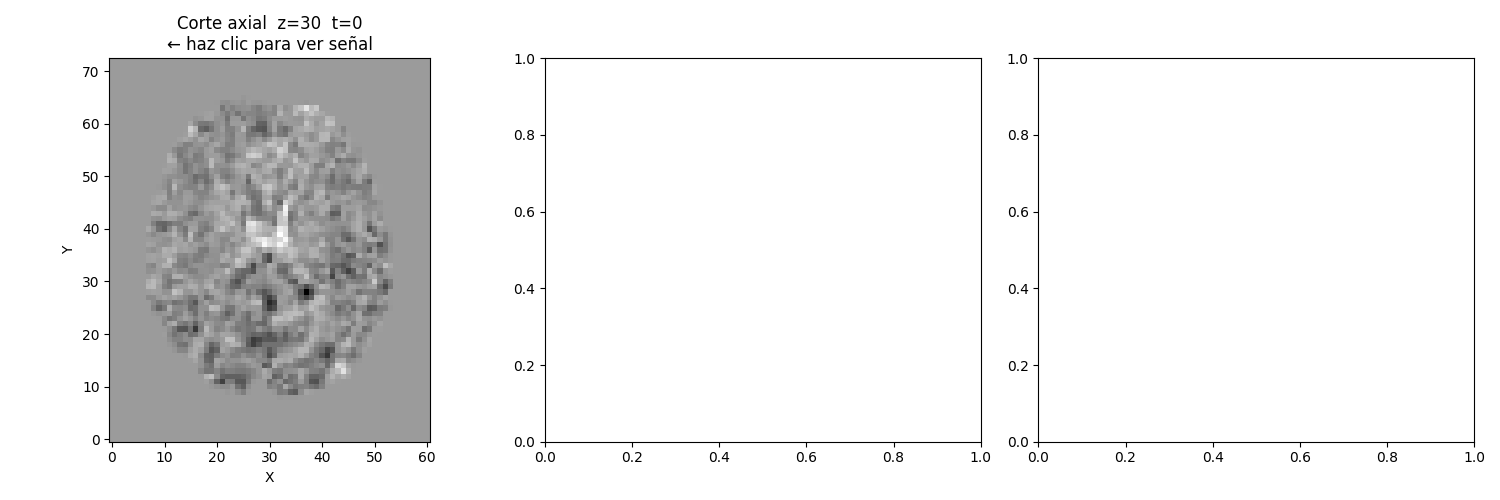

In [4]:
def visor_cerebro(z_init=None, t_init=0):
    """
    Visor unificado:
      - Slider z: navega cortes axiales
      - Slider t: navega el tiempo
      - Clic izquierdo en el cerebro: muestra señal original + filtrada del voxel
    """
    if z_init is None:
        z_init = z_dim // 2

    # Estado mutable (se actualiza desde los callbacks)
    state = {'z': z_init, 't': t_init, 'clicked': None}

    fig = plt.figure(figsize=(15, 5))
    ax_brain  = fig.add_subplot(1, 3, 1)   # corte axial
    ax_orig   = fig.add_subplot(1, 3, 2)   # señal original
    ax_filt   = fig.add_subplot(1, 3, 3)   # señal filtrada

    def draw_brain():
        z, t = state['z'], state['t']
        ax_brain.cla()
        ax_brain.imshow(data[:, :, z, t].T, cmap='gray', origin='lower')
        ax_brain.set_title(f'Corte axial  z={z}  t={t}\n← haz clic para ver señal')
        ax_brain.set_xlabel('X')
        ax_brain.set_ylabel('Y')
        if state['clicked']:
            cx, cy = state['clicked']
            ax_brain.scatter(cx, cy, c='red', s=60, zorder=5)

    def draw_signals(x, y):
        z = state['z']
        sig_orig = data[x, y, z, :]
        sig_filt = bandpass_filter(sig_orig, tr=TR)

        ax_orig.cla()
        ax_orig.plot(sig_orig, color='steelblue', lw=1.2)
        ax_orig.set_title(f'Original — voxel ({x}, {y}, {z})')
        ax_orig.set_xlabel('Tiempo (volúmenes)')
        ax_orig.set_ylabel('Amplitud')

        ax_filt.cla()
        ax_filt.plot(sig_filt, color='tomato', lw=1.2)
        ax_filt.set_title('Filtrada (0.01–0.1 Hz)')
        ax_filt.set_xlabel('Tiempo (volúmenes)')
        ax_filt.set_ylabel('Amplitud')

    def on_click(event):
        if event.inaxes != ax_brain:
            return
        if event.xdata is None or event.ydata is None:
            return
        x = int(round(event.xdata))
        y = int(round(event.ydata))
        if not (0 <= x < x_dim and 0 <= y < y_dim):
            return
        state['clicked'] = (x, y)
        draw_brain()
        draw_signals(x, y)
        fig.canvas.draw_idle()
        print(f'Voxel ({x}, {y}, {state["z"]})')

    # Sliders
    sl_z = widgets.IntSlider(value=z_init, min=0, max=z_dim-1, step=1,
                             description='z (corte):', style={'description_width':'auto'},
                             layout=widgets.Layout(width='400px'))
    sl_t = widgets.IntSlider(value=t_init, min=0, max=t_dim-1, step=1,
                             description='t (tiempo):', style={'description_width':'auto'},
                             layout=widgets.Layout(width='400px'))

    def on_z(change):
        state['z'] = change['new']
        draw_brain()
        fig.canvas.draw_idle()

    def on_t(change):
        state['t'] = change['new']
        draw_brain()
        fig.canvas.draw_idle()

    sl_z.observe(on_z, names='value')
    sl_t.observe(on_t, names='value')
    fig.canvas.mpl_connect('button_press_event', on_click)

    draw_brain()
    plt.tight_layout()
    plt.show()

    display(widgets.VBox([sl_z, sl_t]))


visor_cerebro()


## 3. Mapa de correlación seed-based

Clic en un voxel del corte axial → se calcula la correlación de ese voxel con todos los demás del corte. El mapa resultante muestra qué zonas están funcionalmente conectadas con la semilla.

In [5]:
def correlacion_segura(s1, s2):
    if np.std(s1) == 0 or np.std(s2) == 0:
        return 0.0
    return float(np.corrcoef(s1, s2)[0, 1])


def calcular_mapa_correlacion(x_seed, y_seed, z, filtrar=True):
    """Correlación del voxel semilla con todos los voxeles del corte z."""
    seed = data[x_seed, y_seed, z, :]
    if filtrar:
        seed = bandpass_filter(seed, tr=TR)
    corr_map = np.zeros((x_dim, y_dim))
    for i in range(x_dim):
        for j in range(y_dim):
            vox = data[i, j, z, :]
            if filtrar:
                vox = bandpass_filter(vox, tr=TR)
            corr_map[i, j] = correlacion_segura(seed, vox)
    return corr_map

print('Funciones de correlación definidas.')


Funciones de correlación definidas.


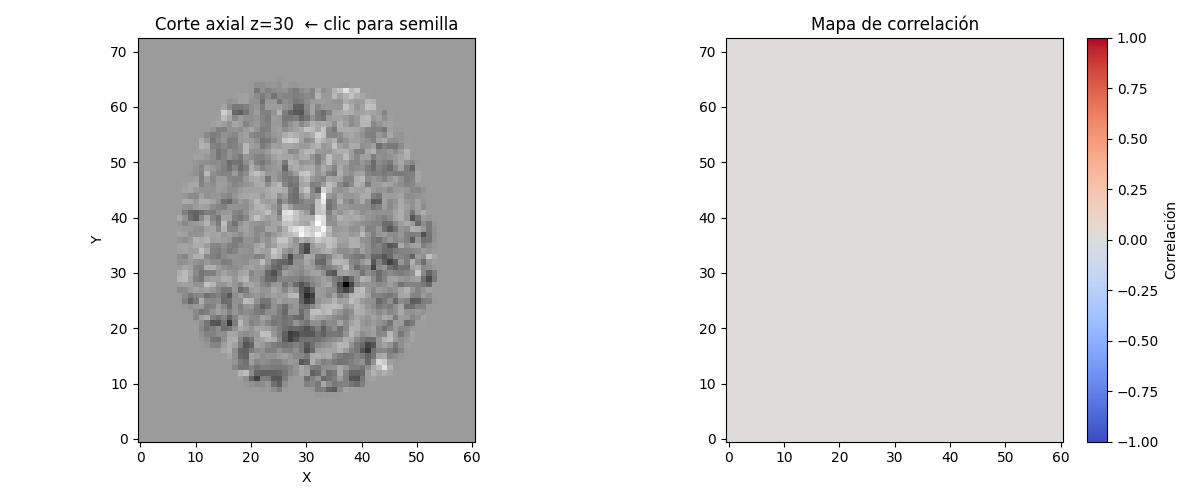

IntSlider(value=30, description='z (corte):', layout=Layout(width='400px'), max=60, style=SliderStyle(descript…

In [6]:
def visor_mapa_correlacion(z_init=None):
    if z_init is None:
        z_init = z_dim // 2
    state = {'z': z_init}

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    def draw_brain(z):
        axes[0].cla()
        axes[0].imshow(data[:, :, z, 0].T, cmap='gray', origin='lower')
        axes[0].set_title(f'Corte axial z={z}  ← clic para semilla')
        axes[0].set_xlabel('X'); axes[0].set_ylabel('Y')

    im_corr = [None]
    cbar    = [None]

    # Mapa vacío inicial
    axes[1].set_title('Mapa de correlación')
    im_corr[0] = axes[1].imshow(
        np.zeros((x_dim, y_dim)).T, cmap='coolwarm',
        origin='lower', vmin=-1, vmax=1
    )
    cbar[0] = fig.colorbar(im_corr[0], ax=axes[1], fraction=0.046, pad=0.04)
    cbar[0].set_label('Correlación')

    def on_click(event):
        if event.inaxes != axes[0] or event.xdata is None:
            return
        x = int(round(event.xdata))
        y = int(round(event.ydata))
        z = state['z']
        if not (0 <= x < x_dim and 0 <= y < y_dim):
            return

        print(f'Calculando mapa para semilla ({x}, {y}, {z})...')
        corr_map = calcular_mapa_correlacion(x, y, z, filtrar=True)

        # Actualizar corte con semilla
        axes[0].cla()
        axes[0].imshow(data[:, :, z, 0].T, cmap='gray', origin='lower')
        axes[0].scatter(x, y, c='red', s=60, zorder=5)
        axes[0].set_title(f'Semilla ({x}, {y}, {z})')
        axes[0].set_xlabel('X'); axes[0].set_ylabel('Y')

        # Actualizar mapa
        axes[1].cla()
        im2 = axes[1].imshow(corr_map.T, cmap='coolwarm', origin='lower', vmin=-1, vmax=1)
        axes[1].scatter(x, y, c='black', s=60, zorder=5)
        axes[1].set_title(f'Mapa correlación — semilla ({x}, {y}, {z})')
        axes[1].set_xlabel('X'); axes[1].set_ylabel('Y')
        cbar[0].update_normal(im2)

        fig.canvas.draw_idle()
        print(f'Listo. Max correlación: {corr_map.max():.3f}')

    sl_z = widgets.IntSlider(value=z_init, min=0, max=z_dim-1, step=1,
                             description='z (corte):', style={'description_width':'auto'},
                             layout=widgets.Layout(width='400px'))

    def on_z(change):
        state['z'] = change['new']
        draw_brain(change['new'])
        fig.canvas.draw_idle()

    sl_z.observe(on_z, names='value')
    fig.canvas.mpl_connect('button_press_event', on_click)

    draw_brain(z_init)
    plt.tight_layout()
    plt.show()
    display(sl_z)


visor_mapa_correlacion()


## 4. Visor de parcelación

Clic en cualquier punto del cerebro → muestra a qué región del atlas pertenece, su nombre, cuántos voxeles tiene, y la señal temporal promedio de esa ROI (original en azul, filtrada en rojo). El slider `z` navega los cortes; el overlay de color muestra el atlas encima del cerebro.

In [7]:
# Cargar atlas y remuestrear al espacio del fMRI
atlas     = datasets.fetch_atlas_harvard_oxford('cort-maxprob-thr25-2mm')
atlas_img = atlas.maps

atlas_resampled      = resample_to_img(atlas_img, fmri_img.slicer[:, :, :, 0], interpolation='nearest')
atlas_resampled_data = atlas_resampled.get_fdata()

# Pre-calcular señal promedio por ROI (filtrada)
roi_ids   = [int(i) for i in np.unique(atlas_resampled_data) if i != 0]
roi_sizes = {rid: int(np.sum(atlas_resampled_data == rid)) for rid in roi_ids}
MIN_VOXELS    = 100
selected_rois = [rid for rid in roi_ids if roi_sizes[rid] >= MIN_VOXELS]

print('Pre-calculando señales ROI...')
roi_signal_cache = {}  # rid -> señal filtrada
roi_names        = {}

for rid in selected_rois:
    mask   = atlas_resampled_data == rid
    sig    = data[mask, :].mean(axis=0)
    roi_signal_cache[rid] = (sig, bandpass_filter(sig, tr=TR))
    name = atlas.labels[rid - 1] if rid - 1 < len(atlas.labels) else f'ROI_{rid}'
    roi_names[rid] = str(name)

print(f'Atlas listo. {len(selected_rois)} ROIs precalculadas.')


Pre-calculando señales ROI...
Atlas listo. 47 ROIs precalculadas.


C:\Users\crist\AppData\Local\Temp\ipykernel_2432\3966749041.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_roi = plt.cm.get_cmap('tab20', n_rois)


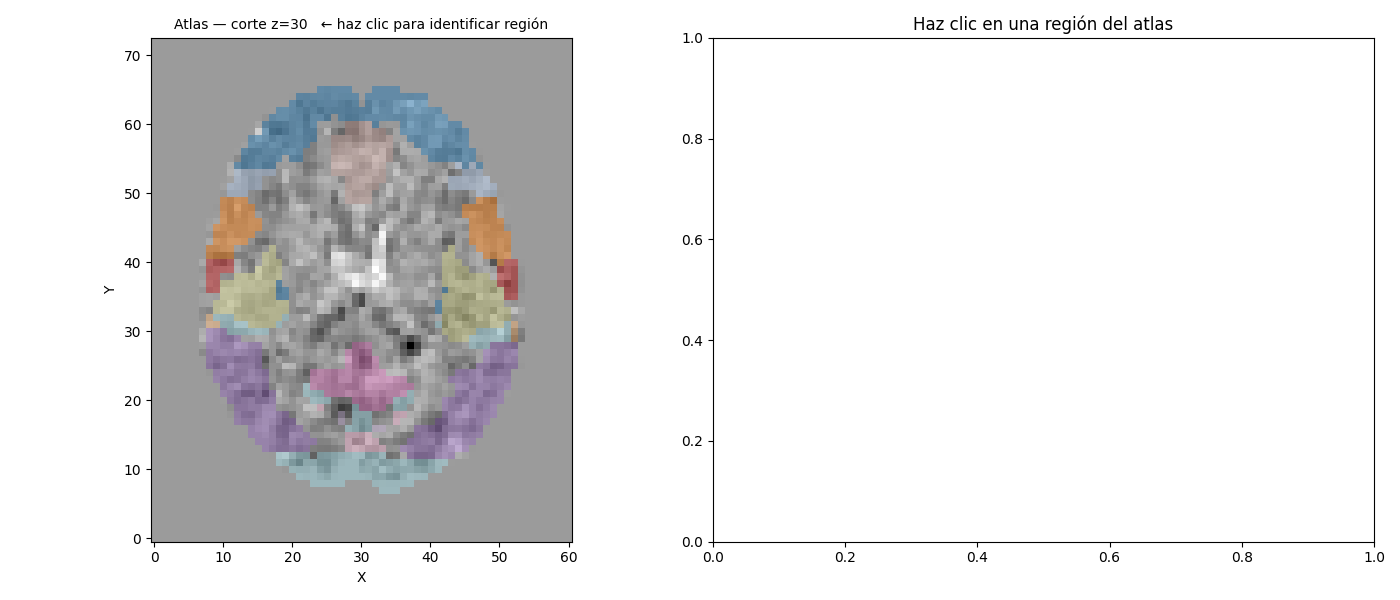

In [8]:
import matplotlib.colors as mcolors

def visor_parcelacion(z_init=None, alpha_atlas=0.45):
    """
    Visor interactivo de parcelación:
      - Panel izquierdo: cerebro + overlay del atlas (coloreado por región)
      - Panel derecho: señal temporal de la ROI seleccionada
      - Clic → identifica ROI, muestra nombre, tamaño y señal orig+filtrada
      - Slider z: navega cortes axiales
      - Slider alpha: transparencia del overlay del atlas
    """
    if z_init is None:
        z_init = z_dim // 2

    # Colormap discreto para el atlas
    n_rois   = len(roi_ids)
    cmap_roi = plt.cm.get_cmap('tab20', n_rois)

    state = {'z': z_init, 'alpha': alpha_atlas, 'roi_sel': None}

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    plt.subplots_adjust(bottom=0.02)

    # ── helpers ──────────────────────────────────────────────────
    def draw_brain():
        z     = state['z']
        alpha = state['alpha']
        roi_s = state['roi_sel']

        axes[0].cla()

        # Cerebro en escala de grises
        axes[0].imshow(data[:, :, z, 0].T, cmap='gray', origin='lower')

        # Overlay atlas: cada ROI con su color
        atlas_slice = atlas_resampled_data[:, :, z].T   # transponer igual que el fMRI
        overlay     = np.zeros((*atlas_slice.shape, 4))  # RGBA

        for idx, rid in enumerate(roi_ids):
            mask_2d = atlas_slice == rid
            if not mask_2d.any():
                continue
            r, g, b, _ = cmap_roi(idx)
            # Resaltar ROI seleccionada con alpha mayor
            a = alpha * 1.8 if rid == roi_s else alpha
            a = min(a, 1.0)
            overlay[mask_2d] = [r, g, b, a]

        axes[0].imshow(overlay, origin='lower')

        # Borde de la ROI seleccionada
        if roi_s is not None:
            mask_2d = atlas_slice == roi_s
            axes[0].contour(mask_2d, levels=[0.5], colors='white', linewidths=1.2)

        axes[0].set_title(
            f'Atlas — corte z={z}   ← haz clic para identificar región',
            fontsize=10
        )
        axes[0].set_xlabel('X')
        axes[0].set_ylabel('Y')

    def draw_signal(rid):
        axes[1].cla()

        if rid not in roi_signal_cache:
            axes[1].set_title(f'ROI {rid} — sin señal (< {MIN_VOXELS} voxeles)')
            return

        sig_orig, sig_filt = roi_signal_cache[rid]
        name  = roi_names.get(rid, f'ROI {rid}')
        nvox  = roi_sizes[rid]

        axes[1].plot(sig_orig, color='steelblue', lw=1.2, alpha=0.7, label='Original')
        axes[1].plot(sig_filt, color='tomato',    lw=1.4, alpha=0.9, label='Filtrada')
        axes[1].set_title(f'{name}\nROI {rid}  —  {nvox} voxeles', fontsize=10)
        axes[1].set_xlabel('Tiempo (volúmenes)')
        axes[1].set_ylabel('Amplitud')
        axes[1].legend(fontsize=8)

    def on_click(event):
        if event.inaxes != axes[0] or event.xdata is None:
            return
        x = int(round(event.xdata))
        y = int(round(event.ydata))
        z = state['z']

        if not (0 <= x < x_dim and 0 <= y < y_dim):
            return

        # Identificar ROI en el punto clicado
        rid = int(atlas_resampled_data[x, y, z])

        if rid == 0:
            print(f'Clic en ({x}, {y}, {z}) — fuera del atlas (fondo)')
            return

        state['roi_sel'] = rid
        name = roi_names.get(rid, f'ROI {rid}')
        nvox = roi_sizes.get(rid, 0)
        print(f'ROI {rid}: {name}  |  {nvox} voxeles  |  voxel ({x}, {y}, {z})')

        draw_brain()
        draw_signal(rid)
        fig.canvas.draw_idle()

    # ── Sliders ──────────────────────────────────────────────────
    sl_z = widgets.IntSlider(
        value=z_init, min=0, max=z_dim - 1, step=1,
        description='z (corte):', style={'description_width': 'auto'},
        layout=widgets.Layout(width='420px')
    )
    sl_alpha = widgets.FloatSlider(
        value=alpha_atlas, min=0.0, max=1.0, step=0.05,
        description='Atlas opacity:', style={'description_width': 'auto'},
        layout=widgets.Layout(width='420px')
    )

    def on_z(change):
        state['z'] = change['new']
        draw_brain()
        fig.canvas.draw_idle()

    def on_alpha(change):
        state['alpha'] = change['new']
        draw_brain()
        fig.canvas.draw_idle()

    sl_z.observe(on_z,     names='value')
    sl_alpha.observe(on_alpha, names='value')
    fig.canvas.mpl_connect('button_press_event', on_click)

    draw_brain()
    axes[1].set_title('Haz clic en una región del atlas')
    plt.tight_layout()
    plt.show()
    display(widgets.VBox([sl_z, sl_alpha]))


visor_parcelacion()


## 5. Matriz de conectividad — Correlación

Calculamos la matriz de correlación de Pearson entre todas las ROIs usando las señales **filtradas** y **normalizadas** (z-score).

In [9]:
# Extraer señales filtradas del cache para la matriz de conectividad
sel_rois_list   = sorted(roi_signal_cache.keys())
roi_signals      = np.array([roi_signal_cache[rid][0] for rid in sel_rois_list]).T  # orig
roi_signals_filt = np.array([roi_signal_cache[rid][1] for rid in sel_rois_list]).T  # filt
roi_names_list   = [roi_names[rid] for rid in sel_rois_list]

print(f'Señales extraídas: {roi_signals_filt.shape}  (tiempo x ROIs)')

# Z-score por ROI antes de correlacionar
def zscore(X):
    mu  = X.mean(axis=0, keepdims=True)
    std = X.std(axis=0,  keepdims=True)
    std[std == 0] = 1
    return (X - mu) / std

roi_signals_norm = zscore(roi_signals_filt)
corr_matrix      = np.corrcoef(roi_signals_norm.T)

upper = corr_matrix[np.triu_indices_from(corr_matrix, k=1)]
print(f'Matriz correlación {corr_matrix.shape}')
print(f'Correlaciones — media: {upper.mean():.3f}  std: {upper.std():.3f}  max: {upper.max():.3f}')


Señales extraídas: (196, 47)  (tiempo x ROIs)
Matriz correlación (47, 47)
Correlaciones — media: 0.517  std: 0.187  max: 0.950


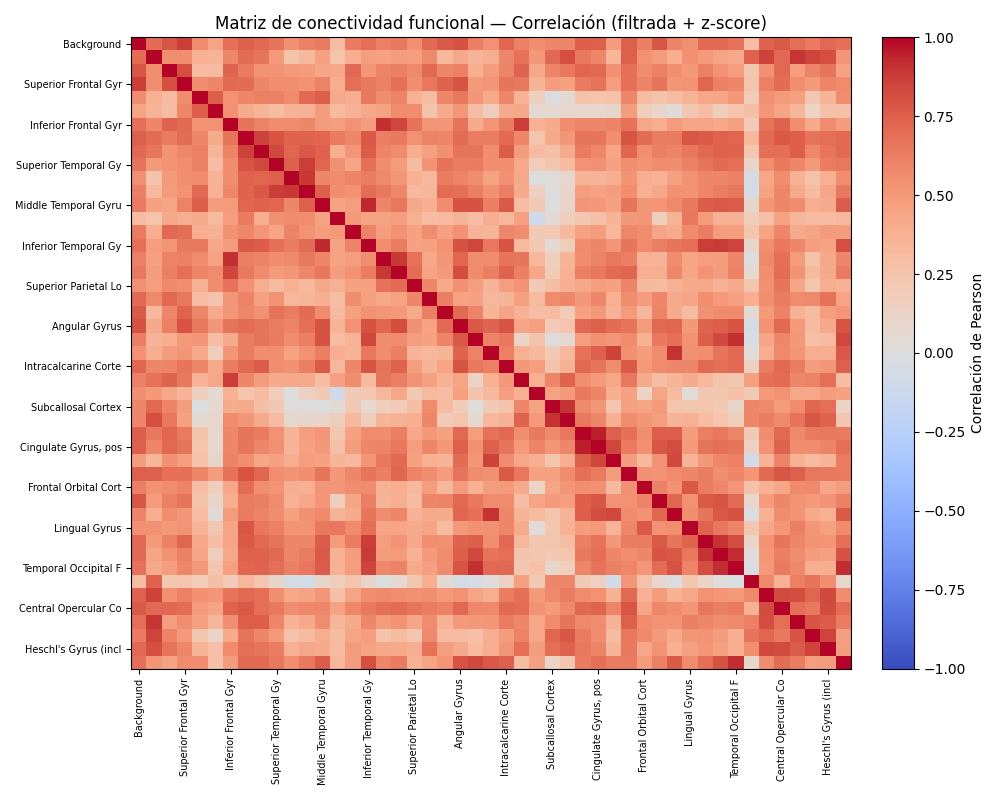

Guardado: resultados/connectivity_correlation.png


In [10]:
n         = len(roi_names_list)
tick_step  = max(1, n // 15)
tick_pos   = list(range(0, n, tick_step))
tick_labels = [roi_names_list[i][:20] for i in tick_pos]

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1, aspect='auto')
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='Correlación de Pearson')
ax.set_xticks(tick_pos); ax.set_xticklabels(tick_labels, rotation=90, fontsize=7)
ax.set_yticks(tick_pos); ax.set_yticklabels(tick_labels, fontsize=7)
ax.set_title('Matriz de conectividad funcional — Correlación (filtrada + z-score)')
plt.tight_layout()
plt.savefig('resultados/connectivity_correlation.png', dpi=150)
plt.show()
print('Guardado: resultados/connectivity_correlation.png')


## 6. Matriz de conectividad — Graphical Lasso

El Graphical Lasso estima la **matriz de precisión** (inversa de la covarianza), que representa conectividad **parcial**: la relación entre dos regiones *controlando* el efecto de todas las demás. Tiende a producir matrices más dispersas (sparse) que la correlación simple.

> **Diferencia clave con correlación:** correlación mide asociación directa *e indirecta*. Graphical Lasso filtra las indirectas → conexiones más limpias y neurobiológicamente interpretables.

In [11]:
from sklearn.covariance import GraphicalLassoCV

# GraphicalLassoCV elige automáticamente el parámetro alpha (regularización)
# con validación cruzada. Usamos las señales filtradas + normalizadas.
print('Ajustando Graphical Lasso (esto puede tardar 1-2 min)...')

glasso = GraphicalLassoCV(cv=5, max_iter=500, n_jobs=-1)
glasso.fit(roi_signals_norm)

# Precisión parcial (conectividad parcial)
precision_matrix = glasso.precision_

# Normalizar a [-1, 1] para comparar visualmente con correlación
# (misma transformación que usa Nilearn internamente)
d = np.sqrt(np.diag(precision_matrix))
partial_corr = -precision_matrix / np.outer(d, d)
np.fill_diagonal(partial_corr, 1.0)

print(f'Alpha seleccionado por CV : {glasso.alpha_:.4f}')
print(f'Shape matriz de precisión : {precision_matrix.shape}')
print(f'Correlaciones parciales — media: {partial_corr[np.triu_indices_from(partial_corr, k=1)].mean():.3f}')


Ajustando Graphical Lasso (esto puede tardar 1-2 min)...
Alpha seleccionado por CV : 0.2072
Shape matriz de precisión : (47, 47)
Correlaciones parciales — media: 0.020


c:\Users\crist\anaconda3\Lib\site-packages\numpy\core\_methods.py:173: RuntimeWarning: invalid value encountered in subtract
  x = asanyarray(arr - arrmean)


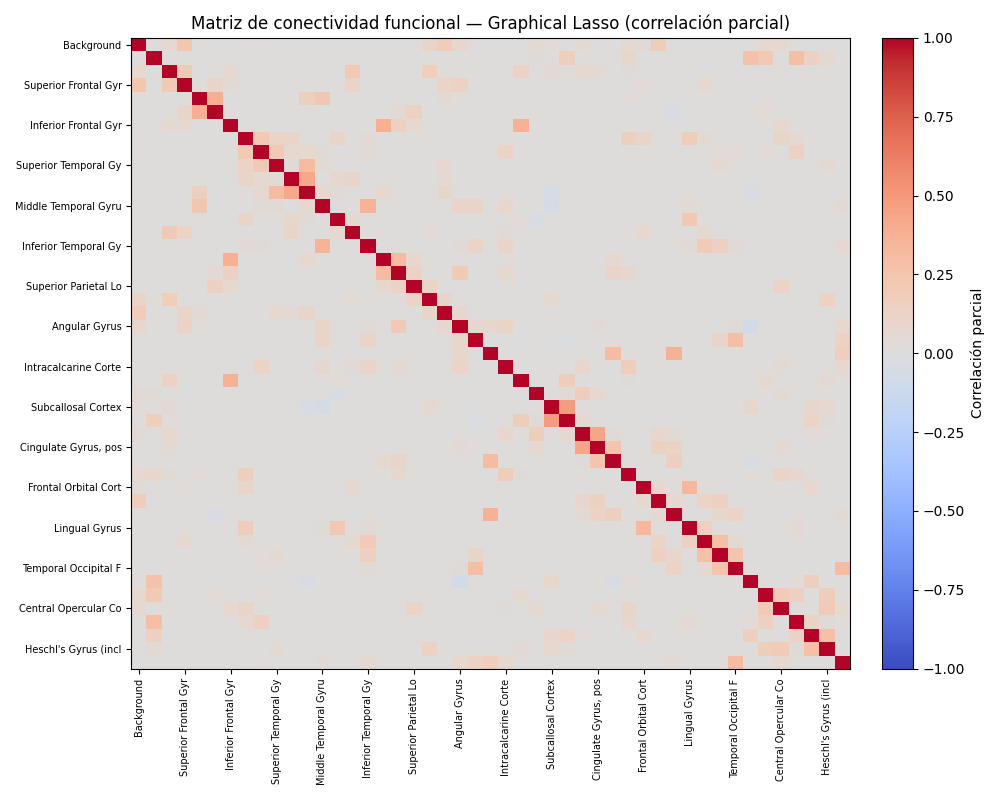

Figura guardada en resultados/connectivity_graphical_lasso.png


In [12]:
# Visualización Graphical Lasso
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(partial_corr, cmap='coolwarm', vmin=-1, vmax=1, aspect='auto')
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='Correlación parcial')
ax.set_xticks(tick_pos); ax.set_xticklabels(tick_labels, rotation=90, fontsize=7)
ax.set_yticks(tick_pos); ax.set_yticklabels(tick_labels, fontsize=7)
ax.set_title('Matriz de conectividad funcional — Graphical Lasso (correlación parcial)')
plt.tight_layout()
plt.savefig('resultados/connectivity_graphical_lasso.png', dpi=150)
plt.show()
print('Figura guardada en resultados/connectivity_graphical_lasso.png')


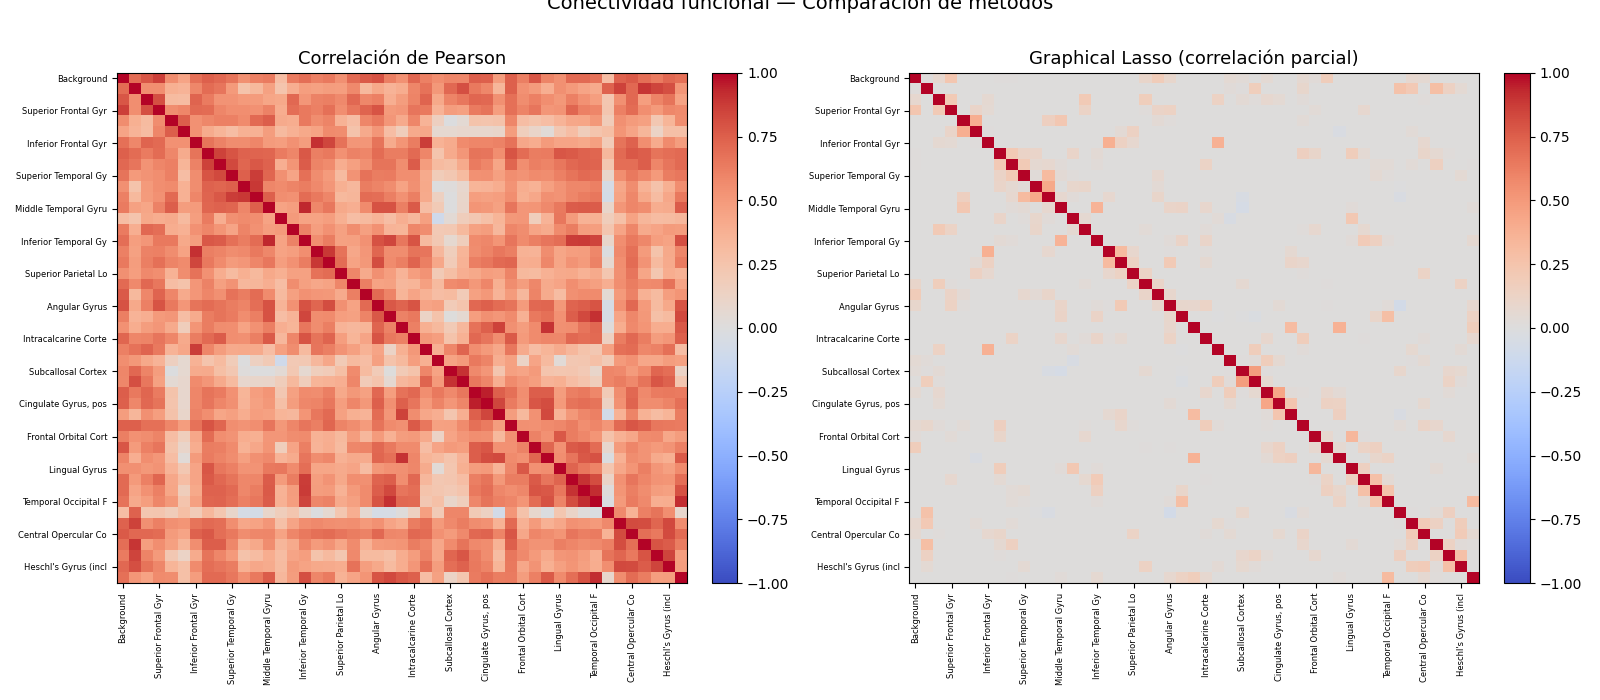

Figura guardada en resultados/comparacion_metodos.png


In [13]:
# Comparación lado a lado: Correlación vs Graphical Lasso
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

im0 = axes[0].imshow(corr_matrix,  cmap='coolwarm', vmin=-1, vmax=1, aspect='auto')
axes[0].set_title('Correlación de Pearson', fontsize=13)
axes[0].set_xticks(tick_pos); axes[0].set_xticklabels(tick_labels, rotation=90, fontsize=6)
axes[0].set_yticks(tick_pos); axes[0].set_yticklabels(tick_labels, fontsize=6)
fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

im1 = axes[1].imshow(partial_corr, cmap='coolwarm', vmin=-1, vmax=1, aspect='auto')
axes[1].set_title('Graphical Lasso (correlación parcial)', fontsize=13)
axes[1].set_xticks(tick_pos); axes[1].set_xticklabels(tick_labels, rotation=90, fontsize=6)
axes[1].set_yticks(tick_pos); axes[1].set_yticklabels(tick_labels, fontsize=6)
fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

plt.suptitle('Conectividad funcional — Comparación de métodos', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('resultados/comparacion_metodos.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura guardada en resultados/comparacion_metodos.png')


## 7. Guardar resultados

Guardamos las matrices y señales para no tener que recalcular. El workflow correcto: bajar sujeto → aplicar pipeline → guardar matrices → borrar datos crudos.

In [14]:
import os
os.makedirs('resultados', exist_ok=True)

np.save('resultados/roi_signals_orig.npy', roi_signals)
np.save('resultados/roi_signals_filt.npy', roi_signals_filt)
np.save('resultados/corr_matrix.npy',      corr_matrix)
np.save('resultados/partial_corr.npy',     partial_corr)
np.save('resultados/selected_rois.npy',    np.array(sel_rois_list))

with open('resultados/roi_names.txt', 'w') as f:
    f.write('\n'.join(roi_names_list))

print('Resultados guardados en resultados/:')
for fname in sorted(os.listdir('resultados')):
    size = os.path.getsize(f'resultados/{fname}')
    print(f'  {fname:<40} {size/1024:.1f} KB')


Resultados guardados en resultados/:
  comparacion_metodos.png                  145.5 KB
  connectivity_correlation.png             138.2 KB
  connectivity_graphical_lasso.png         130.5 KB
  corr_matrix.npy                          17.4 KB
  corr_matrix_roi.npy                      17.4 KB
  partial_corr.npy                         17.4 KB
  roi_names.txt                            1.5 KB
  roi_signals.npy                          72.1 KB
  roi_signals_filt.npy                     72.1 KB
  roi_signals_orig.npy                     72.1 KB
  selected_rois.npy                        0.3 KB
